In [2]:
import pandas as pd
df=pd.read_csv("/content/Pass-Fail Data.csv")
df.info()
df.head()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
count,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000
mean,50.500000,69.520000,69.03000,68.780000,7.28000,0.600000
std,29.011492,17.651783,17.01304,14.717254,3.62115,0.492366
min,1.000000,30.000000,35.00000,42.000000,2.00000,0.000000
25%,25.750000,55.000000,55.00000,56.000000,4.00000,0.000000
50%,50.500000,72.500000,70.00000,68.000000,7.00000,1.000000
75%,75.250000,85.000000,85.00000,82.000000,10.00000,1.000000
max,100.000000,95.000000,96.00000,97.000000,15.00000,1.000000


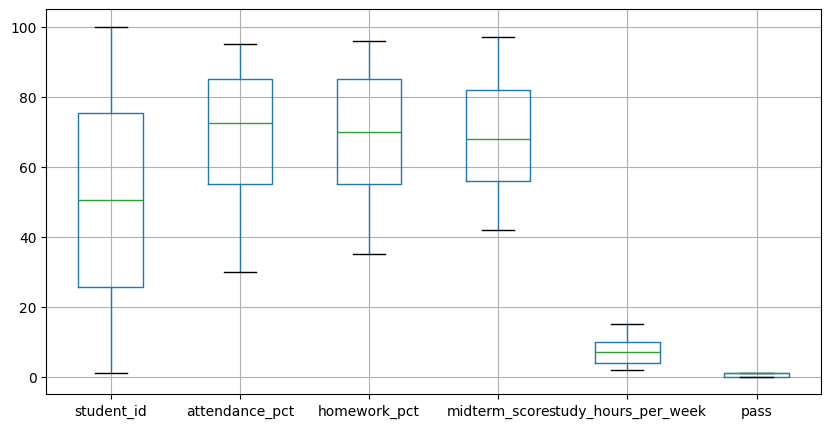

In [18]:
import matplotlib.pyplot as plt

df.boxplot(figsize=(10,5))
plt.show()

In [10]:
df['pass'].unique()
df['student_id'].duplicated().sum()

np.int64(0)

In [3]:
print(df.columns)

Index(['student_id', 'attendance_pct', 'homework_pct', 'midterm_score',
       'study_hours_per_week', 'pass'],
      dtype='object')


In [4]:
print(df.columns.tolist())

['student_id', 'attendance_pct', 'homework_pct', 'midterm_score', 'study_hours_per_week', 'pass']


In [5]:
x=df.drop(["student_id","pass"],axis=1)
y=df["pass"]

In [6]:
print("features:")
print(x.head())

features:
   attendance_pct  homework_pct  midterm_score  study_hours_per_week
0              95            92             88                    12
1              88            85             79                    10
2              60            55             58                     4
3              72            70             65                     6
4              40            45             50                     3


displaying target values

In [7]:
print("target:")
print(y.head())

target:
0    1
1    1
2    0
3    1
4    0
Name: pass, dtype: int64


to split dataset into training and testing data

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("testing data shape:",x_train.shape)
print("testing data shape:",x_test.shape)

testing data shape: (80, 4)
testing data shape: (20, 4)


checking training and testing shapes

In [9]:
print("training feature shape:",x_train.shape)
print("testing feature shape:",x_test.shape)
print("training target shape:",y_train.shape)
print("testing target shape:",y_test.shape)

training feature shape: (80, 4)
testing feature shape: (20, 4)
training target shape: (80,)
testing target shape: (20,)


creating logistic regression model

In [11]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

training model

In [12]:
model.fit(x_train,y_train)

LogisticRegression()

make predictions

In [13]:
y_pred=model.predict(x_test)
print(y_pred)

[1 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1]


comparing actual vs predicted values

In [14]:
comparison=pd.DataFrame({
    "actual":y_test,
    "predicted":y_pred
})
comparison.head(10)

,actual,predicted
83,1,1
53,1,1
70,0,0
45,0,0
44,1,1
39,1,1
22,0,0
80,0,0
10,0,0
0,1,1


calculating accuracy

In [15]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("accuracy:",accuracy)

accuracy: 1.0


generate confusion matrix

In [16]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [17]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[ 8  0]
 [ 0 12]]


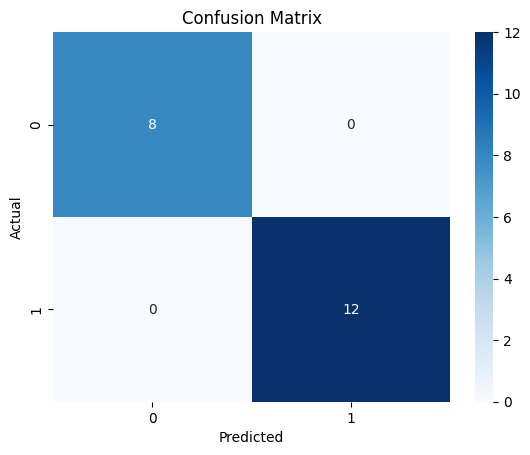

In [19]:
import seaborn as sns
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



model performance summary

In [21]:
print("model accuracyy:",accuracy_score(y_test, y_pred) * 100, "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

model accuracyy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



model check on new data

In [22]:
new_student = [[90, 85, 80, 10]]
prediction = model.predict(new_student)
if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")

Student is likely to PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [24]:
new_student = pd.DataFrame({
    "attendance_pct": [90],
    "homework_pct": [85],
    "midterm_score": [80],
    "study_hours_per_week": [10]
})
prediction = model.predict(new_student)
print(prediction)
if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")

[1]
Student is likely to PASS


probability

In [25]:
probability = model.predict_proba(new_student)
print("Probability of Fail :", round(probability[0][0]*100,2), "%")
print("Probability of Pass :", round(probability[0][1]*100,2), "%")

Probability of Fail : 0.0 %
Probability of Pass : 100.0 %
